In [1]:
pip install keras-facenet mtcnn

  Preparing metadata (setup.py) ... done
ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: '/home/shayan/anaconda3/envs/DataCoLab/lib/python3.8/site-packages/numpy-1.24.3.dist-info/METADATA'


[notice] A new release of pip is available: 24.2 -> 24.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
from keras_facenet import FaceNet
from mtcnn import MTCNN
from sklearn.metrics.pairwise import cosine_similarity
import cv2

# Load FaceNet model
embedder = FaceNet()

# Load the face detector
detector = MTCNN()

# Function to extract face embeddings
def get_face_embedding(image):
    # Detect face
    faces = detector.detect_faces(image)
    if faces:
        # Extract bounding box
        x, y, width, height = faces[0]['box']
        face = image[y:y+height, x:x+width]
        # Resize and preprocess face
        face = cv2.resize(face, (160, 160))
        face = face.astype('float32') / 255.0
        # Extract embedding
        embedding = embedder.embeddings([face])
        return embedding[0]
    return None

# Function to recognize a student by comparing embeddings
def recognize_student(input_image, student_db):
    input_embedding = get_face_embedding(input_image)
    if input_embedding is None:
        return "No face detected!"

    # Compare with student embeddings
    similarities = []
    for student_name, student_embedding in student_db.items():
        similarity = cosine_similarity([input_embedding], [student_embedding])
        similarities.append((student_name, similarity[0][0]))

    # Return the student with the highest similarity
    recognized_student = max(similarities, key=lambda x: x[1])
    return recognized_student[0] if recognized_student[1] > 0.8 else "Unknown"

# Example: Load images for students
student_db = {}
students = ['/content/آرمان شجاع.jpg', '/content/حسین محمدنژاد.jpg', '/content/فاطمه قره زاده.jpg', "/content/محمد مقدم.jpg"]
student_names = ['آرمان شجاع', 'حسین محمدنژاد', 'فاطمه قره زاده', 'محمد مقدم']

for i, img_path in enumerate(students):
    img = cv2.imread(img_path)
    embedding = get_face_embedding(img)
    if embedding is not None:
        student_db[student_names[i]] = embedding



1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Recognized student: آرمان شجاع


In [ ]:
# Test with a new image
test_img = cv2.imread('/content/مقدم2.jpg')
recognized_student = recognize_student(test_img, student_db)
print(f"Recognized student: {recognized_student}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Recognized student: آرمان شجاع


In [ ]:
pip install deepface

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 5.6 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256=e9185716f5380144e56cb4bd2a9b6c06a44e2786f1b49714ccc8cc5b398b721a
  Stored in directory: /root/.cache/pip/wheels/19/39/2f/2d3cadc408a8804103f1c34ddd4b9f6a93497b11fa96fe738e
Successfully built fire


In [ ]:
from deepface import DeepFace
import cv2

# Function to load and preprocess the image
def load_and_preprocess_image(image_path):
    img = cv2.imread(image_path)
    # Preprocess the image to match VGG-Face input requirements
    img = cv2.resize(img, (224, 224))  # Resize to 224x224
    img = img.astype('float32') / 255.0  # Normalize pixel values
    return img

# Function to recognize a student using different models
def recognize_student(image, db, model_name="VGG-Face"):
    for student_name, student_embedding in db.items():
        # Compare the student image with the test image using the chosen model
        result = DeepFace.verify(image, student_embedding, model_name=model_name, enforce_detection=False)
        if result["verified"]:
            return student_name
    return "Unknown"

# Initialize the database with student images
def create_student_db(student_images, model_name="VGG-Face"):
    db = {}
    for student_name, img_path in student_images.items():
        # Load and preprocess the image before representing it
        img = load_and_preprocess_image(img_path)
        # Store the face embedding for each student
        db[student_name] = DeepFace.represent(img, model_name=model_name, enforce_detection=False)[0]["embedding"]
    return db

# List of student images (file paths)
student_images = {
    'آرمان شجاع': '/content/آرمان شجاع.jpg',
    'حسین محمدنژاد': '/content/حسین محمدنژاد.jpg',
    'فاطمه قره زاده': '/content/فاطمه قره زاده.jpg',
    'محمد مقدم': "/content/محمد مقدم.jpg"

}

# Create the student database
student_db = create_student_db(student_images, model_name="VGG-Face")

# Test with a new image (to recognize the student)
test_img = load_and_preprocess_image("/content/مقدم2.jpg") # Preprocess the test image as well
recognized_student = recognize_student(test_img, student_db, model_name="VGG-Face")
print(f"Recognized student: {recognized_student}")

ValueError: The layer sequential_8 has never been called and thus has no defined input.

In [ ]:
# Test with ArcFace model
recognized_student = recognize_student(test_img, student_db, model_name="ArcFace")
print(f"Recognized student with ArcFace: {recognized_student}")

AttributeError: 'KerasHistory' object has no attribute 'layer'

In [ ]:
# Test with Facenet model
recognized_student = recognize_student(test_img, student_db, model_name="Facenet")
print(f"Recognized student with Facenet: {recognized_student}")

24-10-23 21:12:19 - ⚠️ You passed 2-th image as pre-calculated embeddings.Please ensure that embeddings have been calculated for the Facenet model.
Recognized student with Facenet: آرمان شجاع


In [ ]:
# Test with OpenFace model
recognized_student = recognize_student(test_img, student_db, model_name="OpenFace")
print(f"Recognized student with OpenFace: {recognized_student}")

24-10-23 21:12:12 - ⚠️ You passed 2-th image as pre-calculated embeddings.Please ensure that embeddings have been calculated for the OpenFace model.
24-10-23 21:12:13 - ⚠️ You passed 2-th image as pre-calculated embeddings.Please ensure that embeddings have been calculated for the OpenFace model.
24-10-23 21:12:13 - ⚠️ You passed 2-th image as pre-calculated embeddings.Please ensure that embeddings have been calculated for the OpenFace model.
24-10-23 21:12:13 - ⚠️ You passed 2-th image as pre-calculated embeddings.Please ensure that embeddings have been calculated for the OpenFace model.
Recognized student with OpenFace: Unknown


Fine-tuning the VGGFace

In [2]:
pip install mtcnn

  Using cached mtcnn-0.1.1-py3-none-any.whl.metadata (5.8 kB)
ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: '/home/shayan/anaconda3/envs/DataCoLab/lib/python3.8/site-packages/numpy-1.24.3.dist-info/METADATA'


[notice] A new release of pip is available: 24.2 -> 24.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# [MTCNN - Multitask Cascaded Convolutional Networks for Face Detection and Alignment](https://github.com/ipazc/mtcnn)

In [1]:
# example of face detection with mtcnn
from matplotlib import pyplot
from PIL import Image
from numpy import asarray
from mtcnn.mtcnn import MTCNN

# extract a single face from a given photograph
def extract_face(filename, required_size=(224, 224)):
	# load image from file
	pixels = pyplot.imread(filename)
	# create the detector, using default weights
	detector = MTCNN()
	# detect faces in the image
	results = detector.detect_faces(pixels)
	# extract the bounding box from the first face
	x1, y1, width, height = results[0]['box']
	x2, y2 = x1 + width, y1 + height
	# extract the face
	face = pixels[y1:y2, x1:x2]
	# resize pixels to the model size
	image = Image.fromarray(face)
	image = image.resize(required_size)
	face_array = asarray(image)
	return face_array

# load the photo and extract the face
pixels = extract_face('/content/محمد مقدم.jpg')
# plot the extracted face
pyplot.imshow(pixels)
# show the plot
pyplot.show()

ModuleNotFoundError: No module named 'mtcnn'

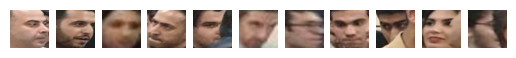

In [ ]:
from matplotlib import pyplot
from PIL import Image
from numpy import asarray
from mtcnn.mtcnn import MTCNN

# Function to extract all faces from an image
def extract_faces(filename, required_size=(224, 224)):
    # Load image from file
    pixels = pyplot.imread(filename)
    # Create the detector, using default weights
    detector = MTCNN()
    # Detect faces in the image
    results = detector.detect_faces(pixels)
    faces = []
    # Loop through all detected faces
    for result in results:
        # Extract the bounding box for each face
        x1, y1, width, height = result['box']
        x2, y2 = x1 + width, y1 + height
        # Extract the face
        face = pixels[y1:y2, x1:x2]
        # Resize the face to the model's required size
        image = Image.fromarray(face)
        image = image.resize(required_size)
        face_array = asarray(image)
        faces.append(face_array)

    return faces

# Load the photo and extract all faces
faces = extract_faces('/content/فرزانه.jpg')

# Plot all extracted faces
for i, face in enumerate(faces):
    pyplot.subplot(1, len(faces), i+1)
    pyplot.axis('off')
    pyplot.imshow(face)

# Show the plot
pyplot.show()

In [1]:
pip install deepface

  Using cached deepface-0.0.93-py3-none-any.whl.metadata (30 kB)
  Using cached gdown-5.2.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached tqdm-4.66.5-py3-none-any.whl.metadata (57 kB)
  Using cached opencv_python-4.10.0.84-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
  Using cached Flask_Cors-5.0.0-py2.py3-none-any.whl.metadata (5.5 kB)
  Using cached retina_face-0.0.17-py3-none-any.whl.metadata (10 kB)
  Using cached fire-0.7.0.tar.gz (87 kB)
  Preparing metadata (setup.py) ... done
  Using cached gunicorn-23.0.0-py3-none-any.whl.metadata (4.4 kB)
  Using cached click-8.1.7-py3-none-any.whl.metadata (3.0 kB)
  Using cached absl_py-2.1.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached wrapt-1.16.0-cp310-cp310-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 743.0 kB/s eta 0:00:00a 

In [1]:
from deepface import DeepFace
import cv2

2024-10-27 21:55:36.218349: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1730053536.231865   14444 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1730053536.235545   14444 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-27 21:55:36.249531: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


24-10-27 21:55:38 - Directory /home/shayan/.deepface has been created
24-10-27 21:55:38 - Directory /home/shayan/.deepface/weights has been created


In [1]:
import cv2
from deepface import DeepFace

cap = cv2.VideoCapture(0)

while True:
    state, frame = cap.read()
    if not state:
        print("Failed to grab frame. Exiting...")
        break

    try:
        res = DeepFace.find(img_path=frame, db_path='/', enforce_detection=False, model_name='Facenet', detector_backend='mtcnn')
        if res and len(res) > 0:  # Check if res has elements
            name = res[0]['identity'].split('/')[-1].split('\\')[-1]
            xmin = int(res[0]['source_x'])
            ymin = int(res[0]['source_y'])
            w = int(res[0]['source_w'])
            h = int(res[0]['source_h'])
            xmax = xmin + w
            ymax = ymin + h

            # Draw rectangle and put text on the frame
            cv2.rectangle(frame, (xmin, ymin), (xmax, ymax), (0, 255, 0), 1)
            cv2.rectangle(frame, (xmin, ymax - 20), (xmax, ymax), (255, 255, 255), -1)
            cv2.putText(frame, name, (xmin, ymin - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2, cv2.LINE_AA)

    except Exception as e:
        print(f"Error: {e}")

    cv2.imshow('attendance', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

2024-11-03 14:49:42.816156: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1730632782.942113   24033 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1730632782.979370   24033 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-03 14:49:43.283996: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
[ WARN:0@5.951] global cap_v4l.cpp:999 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[ERROR:0@5.952] global obse

Failed to grab frame. Exiting...


error: OpenCV(4.10.0) /io/opencv/modules/highgui/src/window.cpp:1295: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvDestroyAllWindows'


In [11]:
model = DeepFace.find(img_path='./moghadam.jpg', db_path='./images', enforce_detection=False, model_name='Facenet', detector_backend='mtcnn')

24-11-04 14:13:15 - Found 9782 newly added image(s), 0 removed image(s), 108 replaced image(s).


Finding representations:   0%|                                                                 | 0/9890 [00:00<?, ?it/s]E0000 00:00:1730716999.869465    1119 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.1.0 but source was compiled with: 9.3.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
2024-11-04 14:13:19.870465: W tensorflow/core/framework/op_kernel.cc:1841] OP_REQUIRES failed at conv_ops_impl.h:1204 : INVALID_ARGUMENT: No DNN in stream executor.
Finding representations:   0%|                                                                 | 0/9890 [00:04<?, ?it/s]


InvalidArgumentError: Exception encountered when calling layer 'Conv2d_1a_3x3' (type Conv2D).

{{function_node __wrapped__Conv2D_device_/job:localhost/replica:0/task:0/device:GPU:0}} No DNN in stream executor. [Op:Conv2D] name: 

Call arguments received by layer 'Conv2d_1a_3x3' (type Conv2D):
  • inputs=tf.Tensor(shape=(1, 160, 160, 3), dtype=float32)

In [10]:
model = DeepFace.find(img_path='./Shayan.jpg', db_path="./Students' Faces", enforce_detection=False, model_name='Facenet512', detector_backend='mtcnn')

24-11-04 14:02:44 - Found 18 newly added image(s), 0 removed image(s), 0 replaced image(s).


Finding representations:   0%|                                                                   | 0/18 [00:00<?, ?it/s]E0000 00:00:1730716367.262747    1119 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.1.0 but source was compiled with: 9.3.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
2024-11-04 14:02:47.264154: W tensorflow/core/framework/op_kernel.cc:1841] OP_REQUIRES failed at conv_ops_impl.h:1204 : INVALID_ARGUMENT: No DNN in stream executor.
2024-11-04 14:02:47.264293: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: INVALID_ARGUMENT: No DNN in stream executor.
Finding representations:   0%|                                                                   | 0/18 [00:02<?, ?it/s]


InvalidArgumentError: Exception encountered when calling layer 'Conv2d_1a_3x3' (type Conv2D).

{{function_node __wrapped__Conv2D_device_/job:localhost/replica:0/task:0/device:GPU:0}} No DNN in stream executor. [Op:Conv2D] name: 

Call arguments received by layer 'Conv2d_1a_3x3' (type Conv2D):
  • inputs=tf.Tensor(shape=(1, 160, 160, 3), dtype=float32)

In [1]:
from deepface import DeepFace

# Define the models you want to use
models = ['Facenet', 'VGGFace2', 'OpenFace']

# List to store embeddings
embeddings = []

# Extract embeddings from each model
for model_name in models:
    result = DeepFace.find(img_path='./moghadam.jpg', db_path='./images', 
                            enforce_detection=False, model_name=model_name, 
                            detector_backend='mtcnn')
    embeddings.append(result)

# Example of averaging embeddings (for simplicity)
# You can apply more complex ensemble techniques as discussed above.
average_embedding = sum(embeddings) / len(embeddings)

# Normalizing the ensemble embedding
average_embedding = average_embedding / np.linalg.norm(average_embedding)

2024-11-04 13:30:09.177891: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1730714409.311776    1119 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1730714409.355529    1119 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-04 13:30:09.823946: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Assuming 'db_embeddings' is a list of normalized embeddings for your database images
# Each entry in db_embeddings should correspond to a precomputed embedding from your database

similarities = [cosine_similarity([average_embedding], [db_emb])[0][0] for db_emb in db_embeddings]

# Get the index of the most similar image in the database
best_match_index = np.argmax(similarities)
best_match_score = similarities[best_match_index]

In [ ]:
threshold = 0.75
if best_match_score >= threshold:
    print(f"Match found with a similarity score of {best_match_score}")
else:
    print("No match found. Similarity score below threshold.")

In [ ]:
# Assuming 'db_images' is a list containing paths or metadata of images in your database
best_match_image = db_images[best_match_index]
print(f"Best match found: {best_match_image} with a similarity score of {best_match_score}")

In [44]:
pip install matplotlib

  Using cached matplotlib-3.9.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached matplotlib-3.9.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (8.3 MB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 245.5 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 247.4 kB/s eta 0:00:00a 0:00:02
Note: you may need to restart the kernel to use updated packages.


# [Image Augmentation](https://manmeet3.medium.com/face-data-augmentation-techniques-ace9e8ddb030)

## Photometric

In [ ]:
import cv2
import numpy as np
import os

# Set the main directory containing folders of each person
base_dir = "./images"

# Create a dictionary for the transformations
transformations = {
    'blurred': lambda img: cv2.GaussianBlur(img, (15, 15), 0),
    'pixelated': lambda img: cv2.resize(cv2.resize(img, (img.shape[1] // 10, img.shape[0] // 10), interpolation=cv2.INTER_LINEAR), (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST),
    'darkened': lambda img: cv2.convertScaleAbs(img, alpha=0.5, beta=0),
    'contrast': lambda img: cv2.convertScaleAbs(img, alpha=2.0, beta=0),
    'edges': lambda img: cv2.Canny(img, 100, 200),
    'embossed': lambda img: cv2.filter2D(img, -1, np.array([[0, -1, -1], [1, 0, -1], [1, 1, 0]])),
    'gray_scale': lambda img: cv2.cvtColor(img, cv2.COLOR_BGR2GRAY),
    'posterized': lambda img: (img // 64) * 64,
    'inverted': lambda img: cv2.bitwise_not(img),
    'noisy': lambda img: cv2.add(img, np.random.normal(0, 25, img.shape).astype(np.uint8)),
    'sepia': lambda img: np.clip(cv2.transform(img, np.array([[0.272, 0.534, 0.131], [0.349, 0.686, 0.168], [0.393, 0.769, 0.189]])), 0, 255).astype(np.uint8),
    'sharpened': lambda img: cv2.filter2D(img, -1, np.array([[-1, -1, -1], [-1, 9, -1], [-1, -1, -1]]))
}

# Iterate over each folder in the base directory
for person_folder in os.listdir(base_dir):
    person_path = os.path.join(base_dir, person_folder)
    if os.path.isdir(person_path):
        # Look for the image in the folder
        for img_name in os.listdir(person_path):
            img_path = os.path.join(person_path, img_name)
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                # Load the original image
                img = cv2.imread(img_path)
                
                # Apply each transformation and save
                for trans_name, trans_func in transformations.items():
                    try:
                        # Apply the transformation
                        transformed_img = trans_func(img)
                        
                        # Save the transformed image in the same directory with a modified name
                        save_path = os.path.join(person_path, f"{trans_name}_{img_name}")
                        cv2.imwrite(save_path, transformed_img)
                        print(f"Saved {trans_name} image for {person_folder} as {save_path}")
                    except Exception as e:
                        print(f"Error applying {trans_name} to {img_name} in {person_folder}: {e}")


## Generic

In [ ]:
import cv2
import os
import numpy as np

# Define the directory containing folders with images of each person
base_dir = './images'

# Function to apply geometric transformations to an image
def apply_transformations(image):
    transformations = {}
    
    # Rotation by 90, 180, and 270 degrees
    transformations['rotate_90'] = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)
    transformations['rotate_180'] = cv2.rotate(image, cv2.ROTATE_180)
    transformations['rotate_270'] = cv2.rotate(image, cv2.ROTATE_90_COUNTERCLOCKWISE)
    
    # Horizontal Flip
    transformations['flip_horizontal'] = cv2.flip(image, 1)
    
    # Vertical Flip
    transformations['flip_vertical'] = cv2.flip(image, 0)
    
    # Translation (shift right and down by 50 pixels)
    rows, cols = image.shape[:2]
    M_translate = np.float32([[1, 0, 50], [0, 1, 50]])
    transformations['translate'] = cv2.warpAffine(image, M_translate, (cols, rows))
    
    # Reflection (mirror both axes)
    transformations['mirror_both'] = cv2.flip(image, -1)
    
    return transformations

# Process each image in each person's folder
for person_name in os.listdir(base_dir):
    person_dir = os.path.join(base_dir, person_name)
    if os.path.isdir(person_dir):
        for img_name in os.listdir(person_dir):
            img_path = os.path.join(person_dir, img_name)
            image = cv2.imread(img_path)

            if image is not None:
                transformations = apply_transformations(image)
                
                # Save each transformed image with a unique name
                for transformation_name, transformed_img in transformations.items():
                    transformed_img_name = f"{os.path.splitext(img_name)[0]}_{transformation_name}.jpg"
                    transformed_img_path = os.path.join(person_dir, transformed_img_name)
                    cv2.imwrite(transformed_img_path, transformed_img)
                
                print(f"Applied transformations for {img_name} in {person_name}'s folder.")
            else:
                print(f"Could not read {img_name} in {person_name}'s folder.")

## [Mask](https://github.com/ternaus/people_segmentation?tab=readme-ov-file)

In [9]:
%matplotlib inline
from pylab import imshow
import numpy as np
import cv2
import torch
import albumentations as albu
!pip install iglovikov_helper_functions
from iglovikov_helper_functions.utils.image_utils import load_rgb, pad, unpad
from iglovikov_helper_functions.dl.pytorch.utils import tensor_from_rgb_image

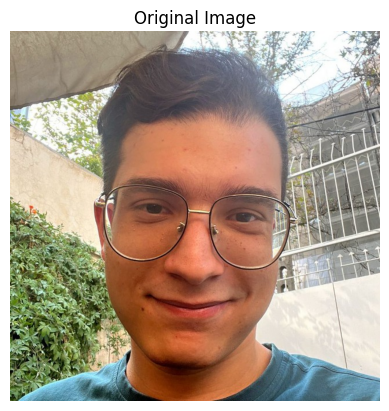

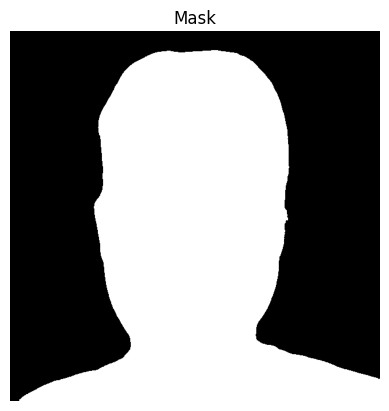

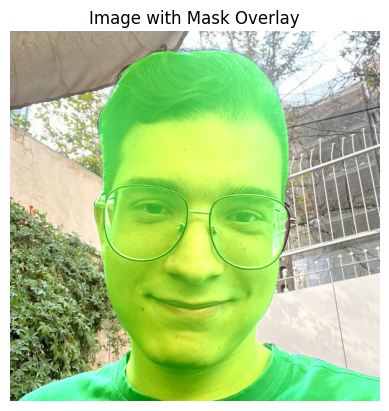

In [13]:
import matplotlib.pyplot as plt
from people_segmentation.pre_trained_models import create_model
import albumentations as albu
import cv2
import numpy as np
import torch

# Load the model
model = create_model("Unet_2020-07-20")
model.eval()

# Load the image
image = load_rgb("Shayan.jpg")
plt.imshow(image)  # Show the original image
plt.title("Original Image")
plt.axis("off")
plt.show()

# Preprocess the image
transform = albu.Compose([albu.Normalize(p=1)], p=1)
padded_image, pads = pad(image, factor=32, border=cv2.BORDER_CONSTANT)
x = transform(image=padded_image)["image"]
x = torch.unsqueeze(tensor_from_rgb_image(x), 0)

# Perform segmentation
with torch.no_grad():
    prediction = model(x)[0][0]

# Generate the mask
mask = (prediction > 0).cpu().numpy().astype(np.uint8)
mask = unpad(mask, pads)

# Convert mask to a PIL image
mask_image = Image.fromarray((mask * 255).astype(np.uint8))  # Multiply by 255 to make it visible

# Save the mask as a PNG file
mask_image.save("mask_Shayan.jpg")

# Display the mask
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")
plt.show()

# Overlay the mask on the original image
dst = cv2.addWeighted(image, 1, (cv2.cvtColor(mask, cv2.COLOR_GRAY2RGB) * (0, 255, 0)).astype(np.uint8), 0.5, 0)
plt.imshow(dst)
plt.title("Image with Mask Overlay")
plt.axis("off")
plt.show()


In [3]:
from diffusers import StableDiffusionInpaintPipeline
import torch
from PIL import Image
import numpy as np

# Load the image and mask
image = Image.open("./Shayan.jpg")  # Path to the image you want to modify
mask_image = Image.open("./mask_Shayan.jpg")  # Path to the mask image

pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "stabilityai/stable-diffusion-2-inpainting",
    torch_dtype=torch.float16,
)
pipe.to("cuda")
prompt = "Turn the facial expression of the person into a sad person"
#image and mask_image should be PIL images.
#The mask structure is white for inpainting and black for keeping as is
image = pipe(prompt=prompt, image=image, mask_image=mask_image).images[0]
# image.save("./sad_Shayan.jpg")

# Convert the image to a NumPy array, clip the values, and save
output_array = np.array(image)
output_array = np.clip(output_array, 0, 1)  # Ensures values are in the correct range
output_image = Image.fromarray((output_array * 255).astype("uint8"))
output_image.save("./sad_Shayan.jpg")


100%|███████████████████████████████████████████████████████████████████████████████████| 50/50 [05:22<00:00,  6.45s/it]


NameError: name 'np' is not defined

In [5]:
import numpy as np
output_array = np.array(image)
output_array = np.clip(output_array, 0, 1)  # Ensures values are in the correct range
output_image = Image.fromarray((output_array * 255).astype("uint8"))
output_image.save("./sad_Shayan.jpg")